**Chapter 3 - Exercise 3.20**

To find Tab:

$$T_{ab} = T_{ab} T_{bc}$$

Transformation Matrix c_T_a for theta = 30 degrees:
[[ 1.      0.      0.      0.    ]
 [ 0.      0.866   0.5     5.6962]
 [ 0.     -0.5     0.866   0.134 ]
 [ 0.      0.      0.      1.    ]]



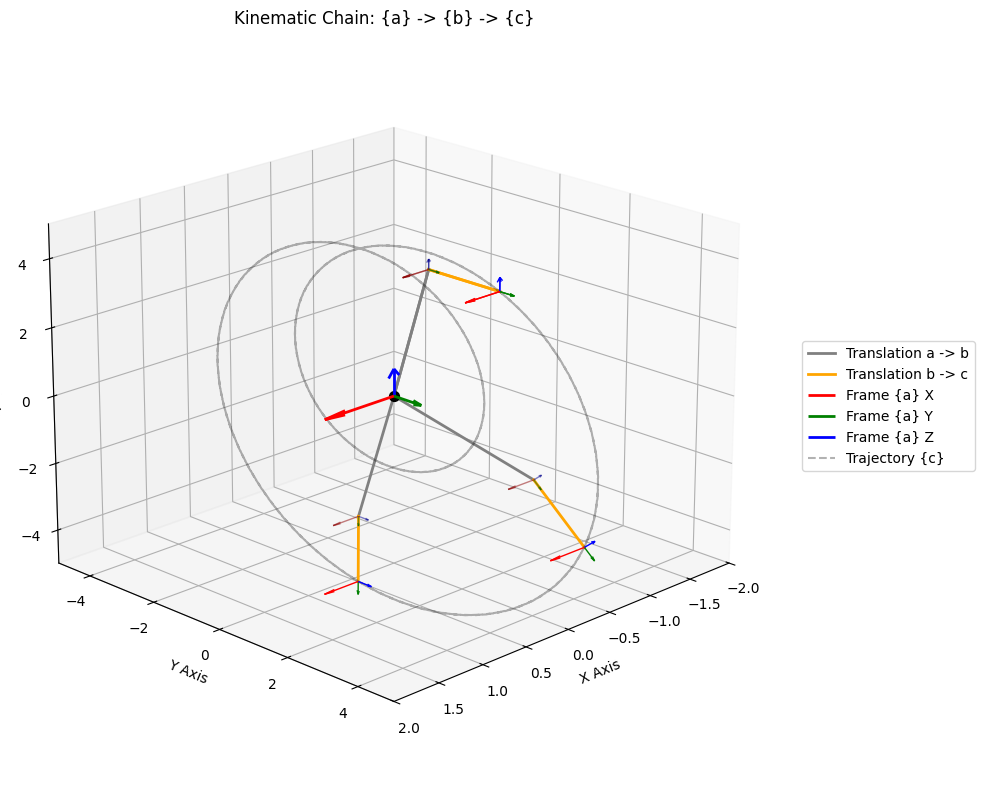

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def get_c_T_b(r, d=0.0):
    c_T_b = np.array([
        [1, 0, 0, -d],
        [0, 1, 0, 2*r],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return c_T_b

def get_b_T_a(theta, r, L):
    cos_b_a = np.cos(-theta)
    sin_b_a = np.sin(-theta)

    b_R_a = np.array([
        [1, 0, 0],
        [0, cos_b_a, -sin_b_a],
        [0, sin_b_a, cos_b_a]
    ])

    cos_2theta = np.cos(-2 * theta)
    sin_2theta = np.sin(-2 * theta)

    a_R_apparent = np.array([
        [1, 0, 0],
        [0, cos_2theta, -sin_2theta],
        [0, sin_2theta, cos_2theta]
    ])

    b_t_a_static = np.array([[0, r, L]]).T
    b_t_a = a_R_apparent @ b_t_a_static

    b_T_a = np.eye(4)
    b_T_a[:3, :3] = b_R_a
    b_T_a[:3, 3] = b_t_a.flatten()

    return b_T_a

def plot_trajectory(r, L, d):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    thetas = np.linspace(0, 4 * np.pi, 200)
    cx, cy, cz = [], [], []
    legend_flags = {'link_ab': False, 'link_bc': False}

    for theta in thetas:
        b_T_a = get_b_T_a(theta, r, L)
        c_T_b = get_c_T_b(r, d)
        c_T_a = b_T_a @ c_T_b

        p_a = np.array([0, 0, 0])
        p_b = b_T_a[:3, 3]
        p_c = c_T_a[:3, 3]

        cx.append(p_c[0])
        cy.append(p_c[1])
        cz.append(p_c[2])

        if np.isclose(theta % (np.pi/4), 0, atol=1e-2):
            label_ab = "Translation a -> b" if not legend_flags['link_ab'] else ""
            ax.plot([p_a[0], p_b[0]], [p_a[1], p_b[1]], [p_a[2], p_b[2]],
                    color='gray', linestyle='-', linewidth=2, label=label_ab)
            legend_flags['link_ab'] = True

            label_bc = "Translation b -> c" if not legend_flags['link_bc'] else ""
            ax.plot([p_b[0], p_c[0]], [p_b[1], p_c[1]], [p_b[2], p_c[2]],
                    color='orange', linestyle='-', linewidth=2, label=label_bc)
            legend_flags['link_bc'] = True

            x_ax = c_T_a[:3, 0] * 0.4
            y_ax = c_T_a[:3, 1] * 0.4
            z_ax = c_T_a[:3, 2] * 0.4
            ax.quiver(*p_c, *x_ax, color='r', linewidth=1)
            ax.quiver(*p_c, *y_ax, color='g', linewidth=1)
            ax.quiver(*p_c, *z_ax, color='b', linewidth=1)

            b_x_ax = b_T_a[:3, 0] * 0.3
            b_y_ax = b_T_a[:3, 1] * 0.3
            b_z_ax = b_T_a[:3, 2] * 0.3
            ax.quiver(*p_b, *b_x_ax, color='darkred', linewidth=1, alpha=0.5)
            ax.quiver(*p_b, *b_y_ax, color='darkgreen', linewidth=1, alpha=0.5)
            ax.quiver(*p_b, *b_z_ax, color='darkblue', linewidth=1, alpha=0.5)

    ax.quiver(0,0,0, 0.8,0,0, color='r', linewidth=2, label='Frame {a} X')
    ax.quiver(0,0,0, 0,0.8,0, color='g', linewidth=2, label='Frame {a} Y')
    ax.quiver(0,0,0, 0,0,0.8, color='b', linewidth=2, label='Frame {a} Z')
    ax.scatter(*p_a, color='black', s=50, zorder=5)

    ax.plot(cx, cy, cz, color='k', linestyle='--', alpha=0.3, label='Trajectory {c}')

    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    ax.set_title("Kinematic Chain: {a} -> {b} -> {c}")

    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    ax.set_xlim([-2, 2])
    ax.set_ylim([-5, 5])
    ax.set_zlim([-5, 5])
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.show()

def main():
    r = 1.0
    L = 4.0
    d = 0.0

    theta_deg = 30
    theta_rad = np.deg2rad(theta_deg)

    b_T_a = get_b_T_a(theta_rad, r, L)
    c_T_b = get_c_T_b(r, d)
    c_T_a = b_T_a @ c_T_b

    np.set_printoptions(precision=4, suppress=True)
    print(f"Transformation Matrix c_T_a for theta = {theta_deg} degrees:\n{c_T_a}\n")

    plot_trajectory(r, L, d)

if __name__ == "__main__":
    main()